# Implementation tests

In [69]:
import sys
from pathlib import Path
import numpy as np
import torch
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd


project_root = Path.cwd().resolve().parents[1]
sys.path.append(str(project_root / "CODE" / "PaperCode"))

from factor_simulation import RiskFactorSimulator

import option_formulas

## Risk factor simulation

In [70]:


# Example inputs
num_risk_factors = 3
initial_spot_values = [100.0, 60.0, 140.0]
drift_array = [0.03, 0.03, 0.03]
volatility_array = [0.10, 0.25, 0.40]
correl_matrix = [
    [1.0, 0.80, 0.10],
    [0.80, 1.0, -0.5],
    [0.10, -0.5, 1.0],
]
# Irregular time grid is allowed
time_steps = np.linspace(0,10,50)
num_sims = 1000

simulator = RiskFactorSimulator(
    num_risk_factors=num_risk_factors,
    initial_spot_values=initial_spot_values,
    drift_array = drift_array,
    volatility_array=volatility_array,
    correl_matrix=correl_matrix,
    time_steps=time_steps
)

paths = simulator.simulate_paths(num_sims=num_sims)


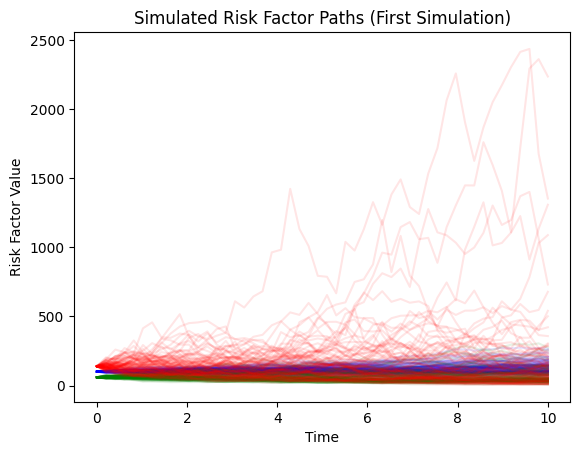

In [71]:
plt.plot(time_steps, paths[:100, :, 0].numpy().T, color='blue', alpha=0.1)
plt.plot(time_steps, paths[:100, :, 1].numpy().T, color='green', alpha=0.1)
plt.plot(time_steps, paths[:100, :, 2].numpy().T, color='red', alpha=0.1)
plt.title("Simulated Risk Factor Paths (First Simulation)")
plt.xlabel("Time")
plt.ylabel("Risk Factor Value")
plt.show()

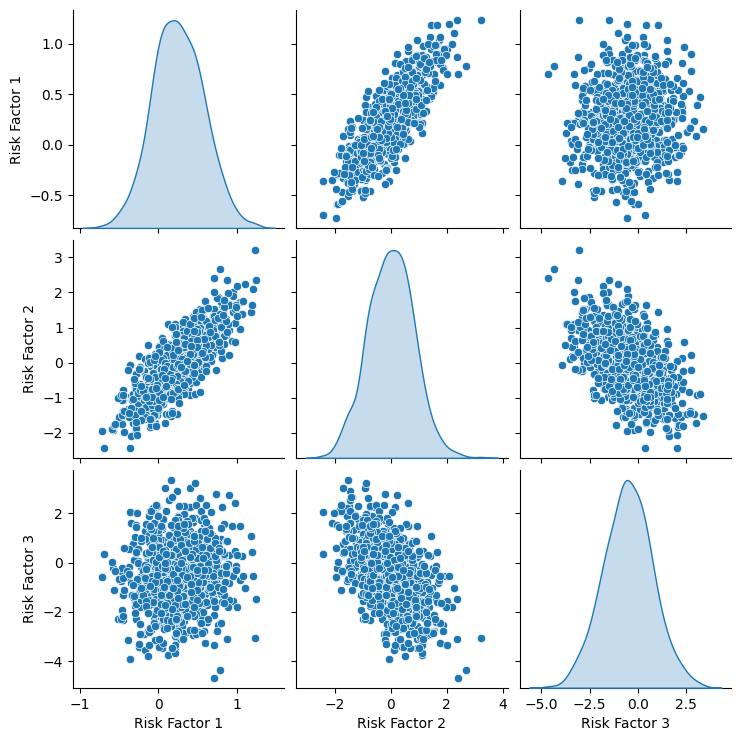

In [72]:
sns.pairplot(
    pd.DataFrame(np.log(paths[:,-1,:].numpy()/paths[:,0,:].numpy()), columns=[f"Risk Factor {i+1}" for i in range(num_risk_factors)]),
    diag_kind="kde")

## Volatility and correlation test

In [73]:
time_steps = [0.0, 0.5, 1.0, 2.5, 5.0, 7.5, 10.0, 15.0, 30.0]

corr_matrix = [[1.0, 0.80, 0.10],
               [0.80, 1.0, -0.5],
                [0.10, -0.5, 1.0]]

simulator = RiskFactorSimulator(
    num_risk_factors=num_risk_factors,
    initial_spot_values=initial_spot_values,
    drift_array = drift_array,
    volatility_array=volatility_array,
    correl_matrix=correl_matrix,
    time_steps=time_steps)

paths = simulator.simulate_paths(num_sims=30000)

for i in range(len(time_steps)-1):

    returns = np.log(paths[:,i+1,:].numpy()/paths[:,i,:].numpy())

    print("Volatilities at time step ", time_steps[i], ":", np.std(returns, axis=0)/np.sqrt(time_steps[i+1]-time_steps[i]))
    print("Correl matrix at time step ", time_steps[i], ":")
    print(np.corrcoef(returns.T))
    



Volatilities at time step  0.0 : [0.10088278 0.25160845 0.40127705]
Correl matrix at time step  0.0 :
[[ 1.          0.80179406  0.10061093]
 [ 0.80179406  1.         -0.4970028 ]
 [ 0.10061093 -0.4970028   1.        ]]
Volatilities at time step  0.5 : [0.10002449 0.25124868 0.40030415]
Correl matrix at time step  0.5 :
[[ 1.          0.80107161  0.09352685]
 [ 0.80107161  1.         -0.50413947]
 [ 0.09352685 -0.50413947  1.        ]]
Volatilities at time step  1.0 : [0.10016338 0.2490531  0.39803779]
Correl matrix at time step  1.0 :
[[ 1.          0.80076496  0.10697565]
 [ 0.80076496  1.         -0.49277201]
 [ 0.10697565 -0.49277201  1.        ]]
Volatilities at time step  2.5 : [0.09992252 0.24755556 0.40039033]
Correl matrix at time step  2.5 :
[[ 1.          0.7967909   0.11675338]
 [ 0.7967909   1.         -0.48975272]
 [ 0.11675338 -0.48975272  1.        ]]
Volatilities at time step  5.0 : [0.10018031 0.24979862 0.39833029]
Correl matrix at time step  5.0 :
[[ 1.          0.8

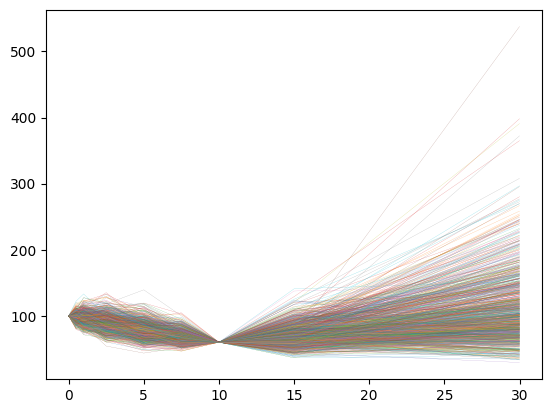

In [74]:
spot_t = [60,140,100]



brown_bridge_paths = simulator.simulate_paths_with_bridge(num_sims = 1000,
        pivot_step_idx = 6,
        spot_at_pivot= spot_t)


plt.plot(time_steps, brown_bridge_paths[:,:,0].T.detach(), linewidth = 0.1);



In [75]:

for i in range(len(time_steps)-1):

    returns = np.log(brown_bridge_paths[:,i+1,:].numpy()/brown_bridge_paths[:,i,:].numpy())

    print("Volatilities at time step ", time_steps[i], ":", np.std(returns, axis=0)/np.sqrt(time_steps[i+1]-time_steps[i]))
    print("Correl matrix at time step ", time_steps[i], ":")
    print(np.corrcoef(returns.T))

Volatilities at time step  0.0 : [0.0983454  0.24531379 0.40218941]
Correl matrix at time step  0.0 :
[[ 1.          0.79406433  0.12224208]
 [ 0.79406433  1.         -0.48819406]
 [ 0.12224208 -0.48819406  1.        ]]
Volatilities at time step  0.5 : [0.09924986 0.24392417 0.38396048]
Correl matrix at time step  0.5 :
[[ 1.          0.81031675  0.09661564]
 [ 0.81031675  1.         -0.48711787]
 [ 0.09661564 -0.48711787  1.        ]]
Volatilities at time step  1.0 : [0.09282217 0.23199285 0.37323651]
Correl matrix at time step  1.0 :
[[ 1.          0.79526268  0.10499257]
 [ 0.79526268  1.         -0.50336019]
 [ 0.10499257 -0.50336019  1.        ]]
Volatilities at time step  2.5 : [0.08835281 0.21885159 0.34733639]
Correl matrix at time step  2.5 :
[[ 1.          0.80332946  0.10337609]
 [ 0.80332946  1.         -0.49226458]
 [ 0.10337609 -0.49226458  1.        ]]
Volatilities at time step  5.0 : [0.09053552 0.22598097 0.34333322]
Correl matrix at time step  5.0 :
[[ 1.          0.8

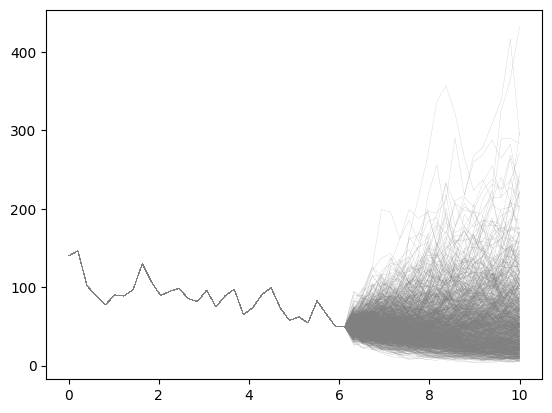

In [76]:
time_steps = np.linspace(0,10,50)


simulator = RiskFactorSimulator(
    num_risk_factors=num_risk_factors,
    initial_spot_values=initial_spot_values,
    drift_array = drift_array,
    volatility_array=volatility_array,
    correl_matrix=correl_matrix,
    time_steps=time_steps)



upto_point_paths = simulator.simulate_same_path_up_do_date(num_sims = 1000,
        pivot_step_idx = 30)



plt.plot(time_steps, upto_point_paths[:,:,2].T.detach(), linewidth = 0.1, color = 'grey');

## Basket option formula

Simulation of risk factors

In [77]:
num_risk_factors = 3
initial_spot_values = [100.0, 60.0, 140.0]
drift_array = [0.03, 0.03, 0.03]
volatility_array = [0.10, 0.25, 0.40]
correl_matrix = [
    [1.0, 0.80, 0.10],
    [0.80, 1.0, -0.5],
    [0.10, -0.5, 1.0],
]
# Irregular time grid is allowed
time_steps = np.linspace(0,5,21)
num_sims = 1000

simulator = RiskFactorSimulator(
    num_risk_factors=num_risk_factors,
    initial_spot_values=initial_spot_values,
    drift_array = drift_array,
    volatility_array=volatility_array,
    correl_matrix=correl_matrix,
    time_steps=time_steps)

paths = simulator.simulate_paths(500)

In [78]:
paths[0]


tensor([[100.0000,  60.0000, 140.0000],
        [103.0120,  66.0962, 112.0197],
        [107.0329,  62.0141, 162.0565],
        [102.3891,  48.9524, 209.3844],
        [104.1105,  51.9647, 197.3696],
        [110.7938,  55.1104, 230.7042],
        [116.2198,  60.4324, 237.6298],
        [117.3839,  60.4377, 228.1977],
        [125.7109,  68.2215, 225.7110],
        [128.7889,  66.8762, 248.2789],
        [126.3882,  64.0546, 234.8331],
        [128.9728,  71.6228, 191.0626],
        [125.7213,  80.5504, 112.0692],
        [115.1681,  66.7941, 107.3979],
        [122.1823,  69.1585, 128.9016],
        [124.9194,  76.3216, 104.8331],
        [127.7217,  70.9037, 135.5992],
        [126.3112,  63.9786, 157.3362],
        [124.7218,  69.8835, 116.4022],
        [124.4140,  84.4903,  63.6624],
        [137.9453,  90.8094,  89.2423]], dtype=torch.float64)

In [79]:

basket_result = option_formulas.basket_geom_asian(init_time_array= torch.tensor(time_steps),
                                                value_date_index= 0, risk_free_rate= 0.03, num_assets= 3,
                                                 assets_vol= torch.tensor(volatility_array),
                                                 assets_correl= torch.tensor(corr_matrix), 
                                                 price_history=paths[0].T, IsCall= True)

basket_result

tensor(0.0628, dtype=torch.float64)

In [80]:
basket_result.numpy()

array(0.06275227)

## Check: scalar vs vectorized basket geometric Asian

This cell compares the scalar and vectorized implementations using the RNN-style path layout `(simulations, time, assets)`.


In [81]:
from option_formulas import basket_geom_asian, basket_geom_asian_vectorized
import torch


init_time_array = torch.as_tensor(time_steps, dtype=torch.float64)
n_assets = int(num_risk_factors)
n_times = len(init_time_array)

# Simulation output is RNN-style: (simulations, time, assets).
price_history = torch.as_tensor(paths, dtype=torch.float64)


risk_free_rate_t = torch.as_tensor(0.03, dtype=torch.float64)
volatility_t = torch.as_tensor(volatility_array, dtype=torch.float64)
correl_t = torch.as_tensor(corr_matrix, dtype=torch.float64)

vec_full = basket_geom_asian_vectorized(
    init_time_array=init_time_array,
    risk_free_rate=risk_free_rate_t,
    num_assets=n_assets,
    assets_vol=volatility_t,
    assets_correl=correl_t,
    price_history=price_history,
    IsCall=True,
)

# Compare only non-terminal dates to avoid scalar maturity edge-case.
vec_values = vec_full[:, :-1, :]

# Force identical dimensions: (simulations, time-1, 1)
scalar_values = torch.empty_like(vec_values)
for sim_index in range(price_history.shape[0]):
    for value_date_index in range(n_times - 1):
        scalar_values[sim_index, value_date_index, 0] = basket_geom_asian(
            init_time_array=init_time_array,
            value_date_index=value_date_index,
            risk_free_rate=risk_free_rate_t,
            num_assets=n_assets,
            assets_vol=volatility_t,
            assets_correl=correl_t,
            price_history=price_history[sim_index].T,
            IsCall=True,
        )

abs_diff = torch.abs(vec_values - scalar_values)

print(f"paths shape:        {tuple(price_history.shape)}")
print(f"vectorized shape:   {tuple(vec_values.shape)}")
print(f"scalar shape:       {tuple(scalar_values.shape)}")
print(f"max abs diff:       {abs_diff.max().item():.3e}")
print(f"mean abs diff:      {abs_diff.mean().item():.3e}")
assert torch.allclose(vec_values, scalar_values, rtol=1e-10, atol=1e-10)


paths shape:        (500, 21, 3)
vectorized shape:   (500, 20, 1)
scalar shape:       (500, 20, 1)
max abs diff:       7.216e-16
mean abs diff:      1.375e-17


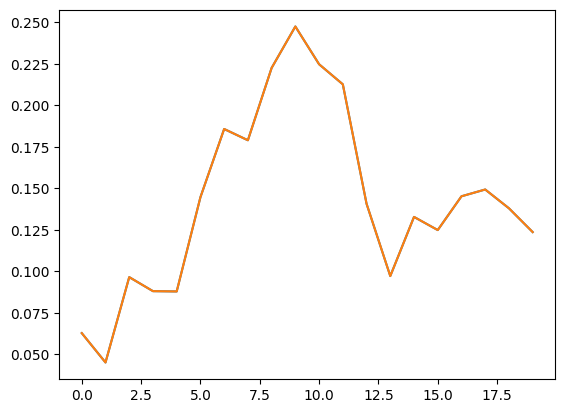

In [82]:
plt.plot(vec_values[0,:,0])
plt.plot(scalar_values[0,:,0])


In [83]:
scalar_values.shape

torch.Size([500, 20, 1])

In [84]:
vec_values.shape

torch.Size([500, 20, 1])

## Check: discounted cash-flow stream

This cell checks that the realized cash-flow generator returns an RNN-style stream and that its Monte Carlo average is consistent with the analytic time-zero price.


In [86]:
from cashflows import basket_geom_asian_cashflows


cashflows = basket_geom_asian_cashflows(
    init_time_array=init_time_array,
    risk_free_rate=risk_free_rate_t,
    num_assets=n_assets,
    price_history=price_history,
    IsCall=True,
)

analytic_t0 = vec_values[:, 0, 0].mean()
mc_t0 = cashflows[:, -1, 0].mean()
abs_diff = torch.abs(mc_t0 - analytic_t0)
std_error = cashflows[:, -1, 0].std(unbiased=True) / torch.sqrt(
    torch.as_tensor(cashflows.shape[0], dtype=torch.float64)
)
confidence_level = 0.95
z_score = torch.as_tensor(1.959963984540054, dtype=torch.float64)
ci_low = mc_t0 - z_score * std_error
ci_high = mc_t0 + z_score * std_error
analytic_in_ci = (ci_low <= analytic_t0) & (analytic_t0 <= ci_high)

print(f"cashflows shape:       {tuple(cashflows.shape)}")
print(f"non-terminal abs sum:  {cashflows[:, :-1, :].abs().sum().item():.3e}")
print(f"MC discounted payoff:  {mc_t0.item():.10f}")
print(f"analytic t0 price:     {analytic_t0.item():.10f}")
print(f"abs diff:              {abs_diff.item():.3e}")
print(f"MC standard error:     {std_error.item():.3e}")
print(f"{confidence_level:.0%} MC CI:             [{ci_low.item():.10f}, {ci_high.item():.10f}]")
print(f"analytic inside CI:    {bool(analytic_in_ci)}")

assert cashflows.shape == (price_history.shape[0], price_history.shape[1], 1)
assert torch.allclose(cashflows[:, :-1, :], torch.zeros_like(cashflows[:, :-1, :]))
assert abs_diff < 4.0 * std_error
assert analytic_in_ci


cashflows shape:       (500, 21, 1)
non-terminal abs sum:  0.000e+00
MC discounted payoff:  0.0588628776
analytic t0 price:     0.0627522690
abs diff:              3.889e-03
MC standard error:     4.221e-03
95% MC CI:             [0.0505894541, 0.0671363012]
analytic inside CI:    True
